# EDA of the eSEEd_v2 emotion dataset

In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import time
import seaborn as sns



## Prepare dataset
- load
- clean

In [114]:
data_dir = "../../data/processed/eSEEd_v2_processed/"
cleaned_data_dir = "../../data/processed/eSEEd_v2_cleaned/"
pupil_cleaned_data_path = os.path.join(cleaned_data_dir, "eSEEd_pupil_cleaned.csv")
pupil_x_y_cleaned_data_path = os.path.join(cleaned_data_dir, "eSEEd_pupil_x_y_cleaned.csv")

In [115]:
def load_eseed_dataset(data_dir: str, cache=True, cached_filename="cached_eseed_dataset.csv") -> pd.DataFrame:
    """Load all CSV files from the processed eSEEd dataset."""
    start_time = time.time()
    if cache:
        cached_path = os.path.join(data_dir, "..", cached_filename)
        if os.path.exists(cached_path):
            print(f"Loading cached eSEEd dataset from {cached_path}...")
            return pd.read_csv(cached_path)
    df = pd.DataFrame()
    for csv_file in os.listdir(data_dir):
        if csv_file.endswith(".csv"):
            df_part = pd.read_csv(os.path.join(data_dir, csv_file))
            df = pd.concat([df, df_part], ignore_index=True)
    print(f"Loaded eSEEd dataset in {time.time() - start_time:.2f} seconds.")
    if cache:
        p = os.path.join(data_dir, "..", cached_filename)
        df.to_csv(p, index=False)
    return df



In [116]:
# df = load_eseed_dataset(data_dir)
df = pd.read_csv(pupil_cleaned_data_path)
dfOG = df.copy()  # keep original for comparison

In [117]:
subjects = df['subject'].unique()
recordings = df['recording'].unique()
emotion_cols = [col for col in df.columns if "emotion" in col]

## Percentage of NaN rows 


In [118]:
# percentage of nan rows (the same for all columns except timestamp, subject, recording)
df = dfOG.copy()
(df.isna().sum() / len(df) * 100)["x-avg"].round(2)

np.float64(0.94)

In [119]:
print("Checking subjects")
for subject in subjects:
    df_subj = df[df['subject'] == subject]
    num_rows = len(df_subj)
    num_nan_rows = df_subj.isna().any(axis=1).sum()
    perc_nan = (num_nan_rows / num_rows) * 100
    if perc_nan > 2:
        print(f"Subject {subject} exceeds {2}% NaN rows: {perc_nan:.2f}% NaN rows ({num_nan_rows}/{num_rows})")

print("\nChecking recordings")
for recording in recordings:
    df_rec = df[df['recording'] == recording]
    num_rows = len(df_rec)
    num_nan_rows = df_rec.isna().any(axis=1).sum()
    perc_nan = (num_nan_rows / num_rows) * 100
    if perc_nan > 1:
        print(f"Recording {recording} exceeds {1}% NaN rows: {perc_nan:.2f}% NaN rows ({num_nan_rows}/{num_rows})")

print("\nChecking emotion columns")
for col in emotion_cols:
    num_rows = len(df)
    num_nan_rows = df[col].isna().sum()
    perc_nan = (num_nan_rows / num_rows) * 100
    print(f"Emotion column {col} exceeds {0}% NaN rows: {perc_nan:.2f}% NaN rows ({num_nan_rows}/{num_rows})")
print("^Same as dataset. Surprise xD")

Checking subjects
Subject 7 exceeds 2% NaN rows: 4.25% NaN rows (3043/71565)
Subject 3 exceeds 2% NaN rows: 21.14% NaN rows (14348/67879)
Subject 46 exceeds 2% NaN rows: 2.40% NaN rows (1743/72523)

Checking recordings
Recording 6 exceeds 1% NaN rows: 2.82% NaN rows (10502/372357)
Recording 10 exceeds 1% NaN rows: 2.12% NaN rows (4612/217143)
Recording 1 exceeds 1% NaN rows: 2.43% NaN rows (6198/255421)
Recording 5 exceeds 1% NaN rows: 1.17% NaN rows (2956/253273)
Recording 9 exceeds 1% NaN rows: 1.35% NaN rows (1870/138259)

Checking emotion columns
Emotion column emotion-anger exceeds 0% NaN rows: 0.94% NaN rows (21984/2340286)
Emotion column emotion-tenderness exceeds 0% NaN rows: 0.94% NaN rows (21984/2340286)
Emotion column emotion-sadness exceeds 0% NaN rows: 0.94% NaN rows (21984/2340286)
Emotion column emotion-disgust exceeds 0% NaN rows: 0.94% NaN rows (21984/2340286)
^Same as dataset. Surprise xD


In [120]:
# put subject and recording columns first
cols = df.columns.tolist()
cols.insert(0, cols.pop(cols.index("subject")))
cols.insert(1, cols.pop(cols.index("recording")))
df = df[cols]


In [121]:
df.columns

Index(['subject', 'recording', 'time-rel-seconds', 'x-avg', 'y-avg',
       'confidence-gaze-left', 'confidence-gaze-right', 'pupil-size-left-avg',
       'pupil-size-right-avg', 'emotion-anger', 'emotion-tenderness',
       'emotion-sadness', 'emotion-disgust'],
      dtype='object')

In [122]:
# clean df
print(len(df[df["x-avg"] < 0]) / len(df))
print(len(df[df["x-avg"] > 1]) / len(df))
print(len(df[df["y-avg"] < 0]) / len(df))
print(len(df[df["y-avg"] > 1]) / len(df))
df = df[df["x-avg"].isna() | ((df["x-avg"] >= 0) & (df["x-avg"] <= 1) & (df["y-avg"] >= 0) & (df["y-avg"] <= 1))]

print(len(df[df["pupil-size-right-avg"] > 10]) / len(df))
print(len(df[df["pupil-size-left-avg"] > 10]) / len(df))
df = df[df["pupil-size-right-avg"].isna() | ((df["pupil-size-right-avg"] < 10) & (df["pupil-size-left-avg"] < 10))]

8.417774579688123e-05
0.0001474178796950458
0.0007140152955664393
0.0003102184946626182
0.0
0.0


## Plot distributions of raw signals per emotion
Signals: x, y, pupil size

['emotion-anger', 'emotion-tenderness', 'emotion-sadness', 'emotion-disgust']


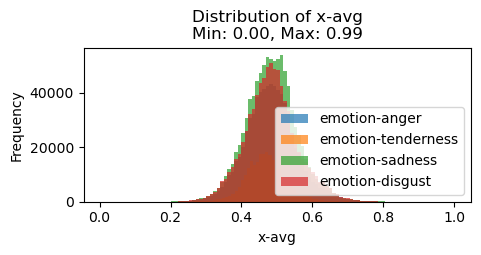

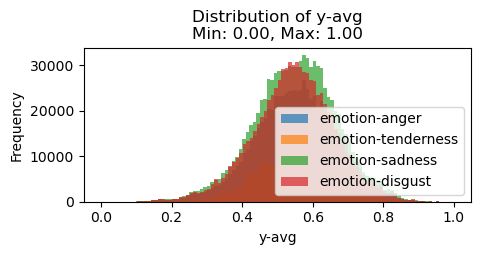

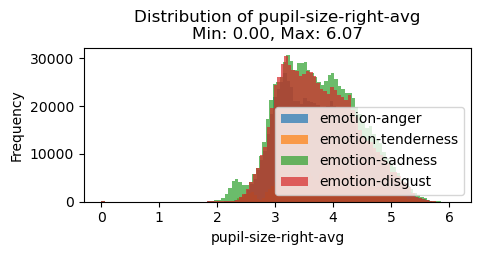

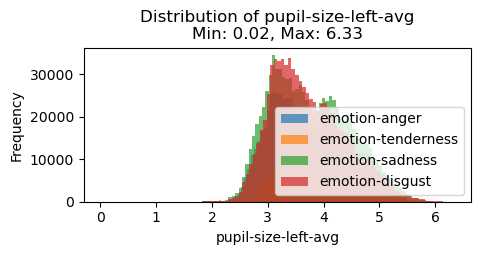

In [123]:
# plot distributions of raw signals per emotion
emotion_cols = [col for col in df.columns if "emotion" in col]
print(emotion_cols)
signals = ["x-avg", "y-avg", "pupil-size-right-avg", "pupil-size-left-avg"]
for signal in signals:
    for tresh in [5]:
        plt.figure(figsize=(5, 2))
        for emotion in emotion_cols:
            data = df.loc[df[emotion] > tresh, signal]
            min_val = data.min()
            max_val = data.max()

            # print(f"Distribution of {signal} for {emotion}:")
            # print(data.describe())
            # print("Percentage of NaN values: ",data.isna().sum()/len(data)*100)
        
            plt.hist(data, bins=100, alpha=0.7, label=emotion)
        plt.title(f"Distribution of {signal}\nMin: {min_val:.2f}, Max: {max_val:.2f}")
        plt.xlabel(signal)
        plt.ylabel("Frequency")
        plt.legend(loc='lower right')
        plt.show()


## Scatter plots: points on screen 
### Colored by emotion

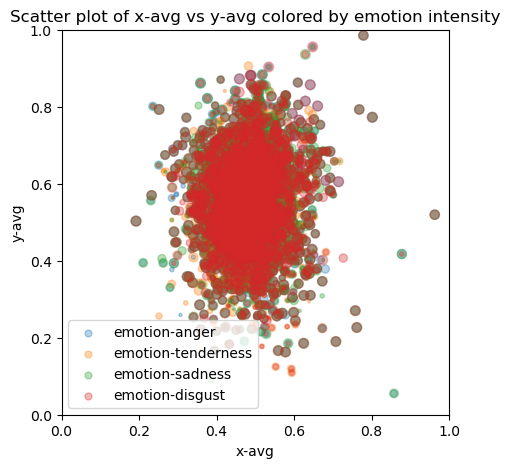

In [124]:
# scatter plot: each emotion is its own color, size according to intensity, x,y coordinates determined by "x-avg" and "y-avg"
emotion_cols = [col for col in df.columns if "emotion" in col]
# random sample to speed up plotting
df_temp = df.sample(n=5000, random_state=111)
plt.figure(figsize=(5, 5))
for emotion in emotion_cols:
    plt.scatter(df_temp["x-avg"], df_temp["y-avg"], s=df_temp[emotion]*5, alpha=0.33, label=emotion)
plt.title(f"Scatter plot of x-avg vs y-avg colored by emotion intensity")
plt.xlabel("x-avg")
plt.ylabel("y-avg")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.show()

## Plot average emotion value for pupil size bins for all emotions



emotion-anger:
Count per bin: [    855  320115 1213991  672269  100173     667       0]

emotion-tenderness:
Count per bin: [    855  320115 1213991  672269  100173     667       0]

emotion-sadness:
Count per bin: [    855  320115 1213991  672269  100173     667       0]

emotion-disgust:
Count per bin: [    855  320115 1213991  672269  100173     667       0]


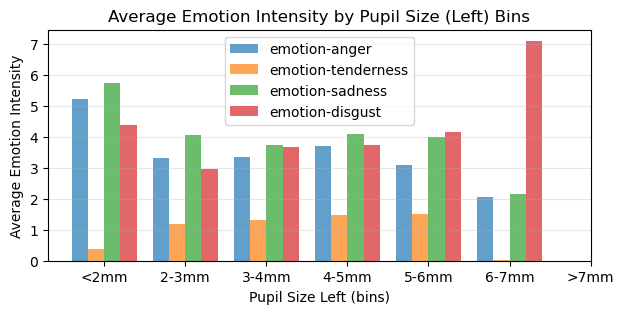

In [125]:
# plot average emotion value for pupil size bins for all emotions
# with shifted centers (side by side)

# Define pupil size bins
pupil_bins = [0, 2, 3, 4, 5, 6, 7, 10]
pupil_labels = ['<2mm', '2-3mm', '3-4mm', '4-5mm', '5-6mm', '6-7mm', '>7mm']

emotion_cols = [col for col in df.columns if "emotion" in col]

plt.figure(figsize=(7, 3))

bar_width = 0.8 / len(emotion_cols)  # Width of each emotion's bars
x_positions = np.arange(len(pupil_labels))

for idx, emotion in enumerate(emotion_cols):
    # Create a copy of the data with non-null values
    df_temp = df[['pupil-size-left-avg', emotion]].dropna()
    
    # Create bins
    df_temp['pupil_bin'] = pd.cut(df_temp['pupil-size-left-avg'], bins=pupil_bins, labels=pupil_labels, include_lowest=True)
    
    # Calculate average emotion for each bin
    avg_emotion_per_bin = df_temp.groupby('pupil_bin',observed=False)[emotion].mean()
    count_per_bin = df_temp.groupby('pupil_bin',observed=False).size()
    
    print(f"\n{emotion}:")
    # print(f"Average per bin: {avg_emotion_per_bin.values}")
    print(f"Count per bin: {count_per_bin.values}")
    
    # Shift bin centers for each emotion
    shifted_positions = x_positions + (idx - len(emotion_cols)/2 + 0.5) * bar_width
    
    # Plot bars
    plt.bar(shifted_positions, avg_emotion_per_bin.values, width=bar_width, alpha=0.7, label=emotion)

plt.xticks(x_positions, pupil_labels)
plt.xlabel('Pupil Size Left (bins)')
plt.ylabel('Average Emotion Intensity')
plt.title('Average Emotion Intensity by Pupil Size (Left) Bins')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()


## Plot average pupil size for each emotion intensity value



emotion-anger:
Count per emotion value: [943027 130789 163838  74878  97382 170581  78927 172457 135776 150353
 190062]

emotion-tenderness:
Count per emotion value: [1632734   77336   95134   90412   67909   92906   56196  103304   50337
   27387   14415]

emotion-sadness:
Count per emotion value: [878758 129319 103857  53264 103978 120016 126605 210008 167031 215444
 199790]

emotion-disgust:
Count per emotion value: [1053642   64295   90727  116079   59988  114699   41138  169548  144504
  189810  263640]


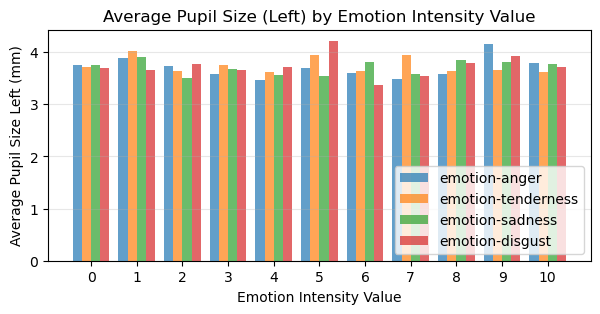

In [126]:
# plot average pupil size for each emotion intensity value
# emotion values are discrete 0-10, plot average pupil size for each emotion value

emotion_cols = [col for col in df.columns if "emotion" in col]

plt.figure(figsize=(7, 3))

bar_width = 0.8 / len(emotion_cols)  # Width of each emotion's bars
emotion_values = np.arange(0, 11)  # 0 to 10

for idx, emotion in enumerate(emotion_cols):
    # Create a copy of the data with non-null values
    df_temp = df[['pupil-size-left-avg', emotion]].dropna()
    
    # Round emotion values to integers (in case they're floats)
    df_temp[emotion] = df_temp[emotion].round().astype(int)
    
    # Calculate average pupil size for each emotion value
    avg_pupil_per_emotion = df_temp.groupby(emotion)['pupil-size-left-avg'].mean()
    count_per_emotion = df_temp.groupby(emotion).size()
    
    print(f"\n{emotion}:")
    print(f"Count per emotion value: {count_per_emotion.values}")
    
    # Reindex to include all emotion values 0-10, fill missing with NaN
    avg_pupil_per_emotion = avg_pupil_per_emotion.reindex(emotion_values)
    
    # Shift bin centers for each emotion
    shifted_positions = emotion_values + (idx - len(emotion_cols)/2 + 0.5) * bar_width
    
    # Plot bars (only where we have data)
    plt.bar(shifted_positions, avg_pupil_per_emotion.values, width=bar_width, alpha=0.7, label=emotion)

plt.xticks(emotion_values)
plt.xlabel('Emotion Intensity Value')
plt.ylabel('Average Pupil Size Left (mm)')
plt.title('Average Pupil Size (Left) by Emotion Intensity Value')
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.show()


## Emotion distributions

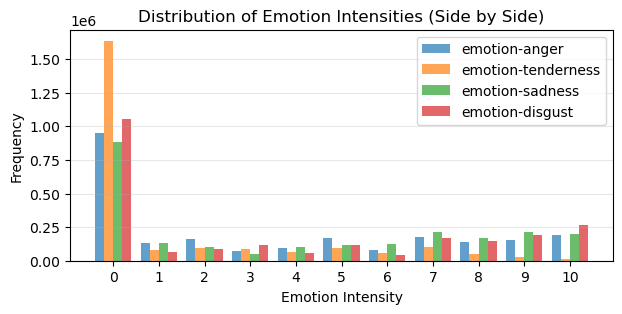

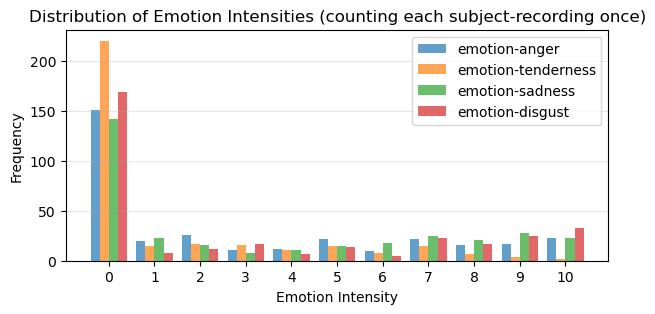

In [127]:
# =========================================================================
# plot emotion distributions
# =========================================================================
exclude_zero = 0

emotion_cols = [col for col in df.columns if "emotion" in col]
plt.figure(figsize=(7, 3))
# Define discrete bins for emotion values (1-10)
bins = np.arange(-0.5+exclude_zero, 11.5, 1)  # Creates bins centered at 1, 2, ..., 10
bar_width = 0.8 / len(emotion_cols)  # Width of each emotion's bars

for idx, emotion in enumerate(emotion_cols):
    data = df[emotion].dropna()
    min_val = data.min()
    max_val = data.max()
    
    # Calculate histogram
    counts, bin_edges = np.histogram(data, bins=bins)
    
    # Shift bin centers for each emotion
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    shifted_centers = bin_centers + (idx - len(emotion_cols)/2 + 0.5) * bar_width
    
    # Plot as bar chart
    plt.bar(shifted_centers, counts, width=bar_width, alpha=0.7, label=emotion)
    
    # print(f"{emotion}: Min={min_val:.2f}, Max={max_val:.2f}, Count={len(data)}")

plt.title(f"Distribution of Emotion Intensities (Side by Side)")
plt.xlabel("Emotion Intensity")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.xticks(range(0+exclude_zero, 11))
plt.show()

# =========================================================================
# count each (subject, recording) pair once
# =========================================================================


# keep exactly one row per (subject, recording) so each pair is counted once
df_sr = df.dropna().drop_duplicates(subset=["subject", "recording"])[["subject", "recording"] + emotion_cols]

plt.figure(figsize=(7, 3))
bins = np.arange(-0.5 + exclude_zero, 11.5, 1)  # bins centered at 1..10 (or 0..10 if exclude_zero=0)
bar_width = 0.8 / len(emotion_cols)

for idx, emotion in enumerate(emotion_cols):
    data = df_sr[emotion].dropna()
    min_val, max_val = data.min(), data.max()

    counts, bin_edges = np.histogram(data, bins=bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    shifted_centers = bin_centers + (idx - len(emotion_cols)/2 + 0.5) * bar_width

    plt.bar(shifted_centers, counts, width=bar_width, alpha=0.7, label=emotion)
    # print(f"{emotion}: Min={min_val:.2f}, Max={max_val:.2f}, Count={len(data)}")

plt.title("Distribution of Emotion Intensities (counting each subject-recording once)")
plt.xlabel("Emotion Intensity")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.xticks(range(0 + exclude_zero, 11))
plt.show()

### Emotion distr. for each subject separately
Warning: 48 plots.

In [128]:
run_this_cell = False

if run_this_cell:
    # plot emotion distributions for each subject
    exclude_zero = 0

    emotion_cols = [col for col in df.columns if "emotion" in col]
    subjects = df['subject'].unique()

    for subject in subjects:
        plt.figure(figsize=(7, 4))
        
        # keep exactly one row per (subject, recording) so each pair is counted once
        df_temp = df[df['subject'] == subject]
        df_sr = df_temp.dropna().drop_duplicates(subset=["recording"])[["recording"] + emotion_cols]

        bins = np.arange(-0.5 + exclude_zero, 11.5, 1)  # bins centered at 1..10 (or 0..10 if exclude_zero=0)
        bar_width = 0.8 / len(emotion_cols)

        for idx, emotion in enumerate(emotion_cols):
            data = df_sr[emotion].dropna()
            min_val, max_val = data.min(), data.max()

            counts, bin_edges = np.histogram(data, bins=bins)
            bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
            shifted_centers = bin_centers + (idx - len(emotion_cols)/2 + 0.5) * bar_width

            plt.bar(shifted_centers, counts, width=bar_width, alpha=0.7, label=emotion)
            # print(f"{emotion}: Min={min_val:.2f}, Max={max_val:.2f}, Count={len(data)}")

        plt.title("Distribution of Emotion Intensities (counting each subject-recording once)")
        plt.xlabel("Emotion Intensity")
        plt.ylabel("Frequency")
        plt.grid(axis="y", alpha=0.3)
        plt.legend()
        plt.xticks(range(0 + exclude_zero, 11))
        plt.show()

### Average emotion intensity by recording

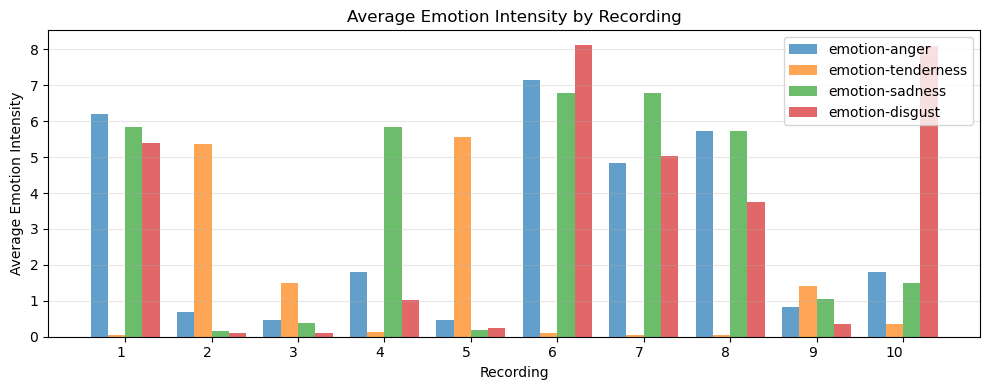

In [129]:
# keep exactly one row per (subject, recording) so each pair is counted once
df_sr = df.dropna().drop_duplicates(subset=["subject", "recording"])[["subject", "recording"] + emotion_cols]

# calculate average emotion intensity per recording
recordings = df_sr["recording"].unique()
recordings.sort()
avg_intensity_per_recording = {}

for emotion in emotion_cols:
    avg_intensity_per_recording[emotion] = df_sr.groupby("recording")[emotion].mean()

# plot
plt.figure(figsize=(10, 4))
bar_width = 0.8 / len(emotion_cols)
x_positions = np.arange(len(recordings))

for idx, emotion in enumerate(emotion_cols):
    avg_values = [avg_intensity_per_recording[emotion].get(rec, 0) for rec in recordings]
    shifted_positions = x_positions + (idx - len(emotion_cols)/2 + 0.5) * bar_width
    plt.bar(shifted_positions, avg_values, width=bar_width, alpha=0.7, label=emotion)

plt.xticks(x_positions, recordings, ha='right')
plt.xlabel("Recording")
plt.ylabel("Average Emotion Intensity")
plt.title("Average Emotion Intensity by Recording")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

#### Intended emotions by recording
| Index | Movie | Duration | Emotion |
|---- | ----| ----| ----|   
|1 | American history X | 1.17 | Anger| 
|2 | Benny and Joon | 2.01 | Tenderness| 
|3 | Blue (2) | 0.40 | Neutral| 
|4 | Ghost | 1.19 | Tenderness| 
|5 | Man bites dog (1) | 1.32 | Disgust| 
|6 | Schindler’s list (1) | 0.58 | Sadness| 
|7 | Schindler’s list (2) | 1.55 | Anger| 
|8 | The dreamlife of angels | 2.00 | Sadness| 
|9 | The lover | 0.43 | Neutral| 
|10 | Trainspotting (2) | 1.00 | Disgust| 

### Number of Subjects by Unique Emotion Intensities Reported 

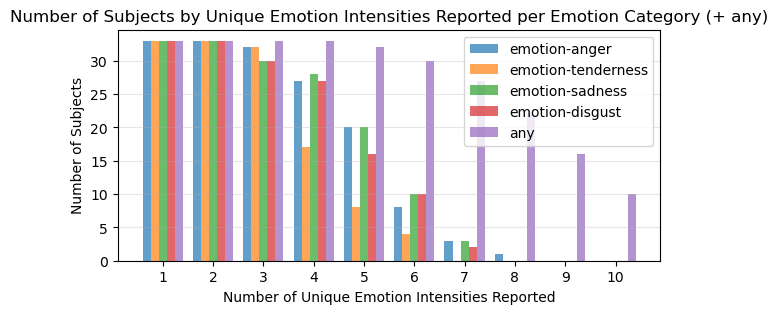

In [130]:

emotion_cols = [c for c in df.columns if "emotion" in c]
emo_plus_any = emotion_cols + ["any"]

subjects = df["subject"].unique()
max_unique_intensities = 10  # intensities 1..10
unique_intensity_counts = {e: np.zeros(max_unique_intensities, dtype=int) for e in emo_plus_any}

for subject in subjects:
    df_temp = df[df["subject"] == subject]

    # one row per recording for this subject (emotion constant per subject-recording)
    df_sr = df_temp.dropna(subset=["recording"]).drop_duplicates(subset=["recording"])[["recording"] + emotion_cols]

    # "any": total number of unique emotion values across all emotion columns & recordings for this subject
    # (values in 1..10; NaNs ignored)
    any_vals = pd.unique(df_sr[emotion_cols].to_numpy().ravel())
    any_vals = any_vals[~pd.isna(any_vals)]
    num_unique_any = len(any_vals)
    for i in range(min(num_unique_any, max_unique_intensities)):
        unique_intensity_counts["any"][i] += 1

    # per-emotion
    for emotion in emotion_cols:
        unique_intensities = df_sr[emotion].dropna().unique()
        num_unique = len(unique_intensities)
        for i in range(min(num_unique, max_unique_intensities)):
            unique_intensity_counts[emotion][i] += 1

# plot
plt.figure(figsize=(7, 3))
bar_width = 0.8 / len(emo_plus_any)
x_positions = np.arange(max_unique_intensities) + 1  # 1..10

for idx, emotion in enumerate(emo_plus_any):
    counts = unique_intensity_counts[emotion]
    shifted_positions = x_positions + (idx - len(emo_plus_any)/2 + 0.5) * bar_width
    plt.bar(shifted_positions, counts, width=bar_width, alpha=0.7, label=emotion)

plt.xticks(x_positions)
plt.xlabel("Number of Unique Emotion Intensities Reported")
plt.ylabel("Number of Subjects")
plt.title("Number of Subjects by Unique Emotion Intensities Reported per Emotion Category (+ any)")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

## Number of subject-recording pairs with all emotions reported as <= `thresh`

In [131]:
# how many subject, recording pairs have all emotions reported as <= thresh
# keep exactly one row per (subject, recording) so each pair is counted once
df_sr = df.dropna().drop_duplicates(subset=["subject", "recording"])[["subject", "recording"] + emotion_cols]

# check if all emotions are <= thresh for each (subject, recording) pair
thresh = 1
all_zero = (df_sr[emotion_cols] <= thresh).all(axis=1)

num_all_zero = all_zero.sum()
print(f"Number of subject-recording pairs with all emotions reported <= {thresh}: {num_all_zero}")
print(f"Subject-recording pairs with all emotions reported <= {thresh}:")
print(df_sr.loc[all_zero, ["subject", "recording"]])

Number of subject-recording pairs with all emotions reported <= 1: 38
Subject-recording pairs with all emotions reported <= 1:
         subject  recording
397187        38          9
430232        26          9
470135         4          2
669696        33          3
693973        26          3
801049        11          4
824187        26          7
867366        47          9
879648        44          3
890235        23          9
900077        11          9
917945        25          3
940571        11          8
994455        23          3
1130570       29          9
1134854       26          2
1423338       29          3
1633071       25          4
1676130        9          3
1756522        7          3
1760102       30          9
1764391       19          3
1794754       25          9
1799043        3          3
1802553        3          9
1817149       43          3
1900085       26          8
1946434       26          4
1969247        2          3
1981582        1          3
20013

`df_sr` is subject-recording aggregated df

In [132]:
df = dfOG.copy() 
df_sr = df.dropna().groupby(["subject", "recording"]).mean(numeric_only=True).reset_index()


In [133]:
neutral_combinations = (df_sr[emotion_cols] == 0).all(axis=1).sum()
print(f"Number of netural subj-rec combinations: {neutral_combinations}. All combinations: {len(df_sr)}")

Number of netural subj-rec combinations: 21. All combinations: 330


## Outliers based on z-score of averages
### Outliers - Subject-recording paris 
- if score_l2 ~ score_max => then one metric dominates the outlier score, others are not contributing much

In [134]:
def robust_z(x):
    med = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - med))
    if mad == 0 or np.isnan(mad):
        return (x - med) * 0.0
    return 0.6745 * (x - med) / mad  # consistent w/ std for normal

def compute_outliers(df, cols):
    Z = df[cols].apply(robust_z, axis=0)
    df['outlier_score_l2'] = np.sqrt((Z**2).sum(axis=1))
    df['outlier_score_max'] = Z.abs().max(axis=1)

    # flag top outliers
    df = df.sort_values('outlier_score_l2', ascending=False)

    return df


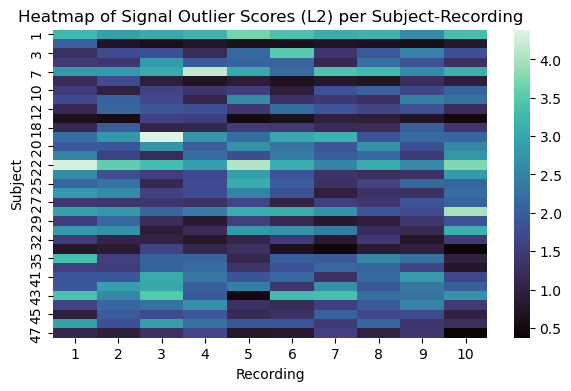

,subject,recording,outlier_score_l2,outlier_score_max,x-avg,y-avg,pupil-size-left-avg,pupil-size-right-avg
112,19,3,4.387232,3.577706,0.565530,0.836582,3.360593,3.361096
140,22,1,4.290128,2.392642,0.398824,0.680731,5.274768,5.157932
43,7,4,4.153174,3.811412,0.613205,0.618962,2.905422,3.201019
144,22,5,4.056911,2.787498,0.385179,0.634152,5.079528,4.955172
199,28,10,3.986809,2.761873,0.454828,0.658343,5.573173,5.350977
149,22,10,3.771895,2.676921,0.389000,0.586225,5.206768,4.648286


In [135]:
# outliers based on signals 
signal_cols = ['x-avg', 'y-avg', 'pupil-size-left-avg', 'pupil-size-right-avg']
df_sr = compute_outliers(df_sr, signal_cols)

plt.figure(figsize=(7, 4))
sns.heatmap(df_sr.pivot(index='subject', columns='recording', values='outlier_score_l2'), cmap='mako')
plt.title('Heatmap of Signal Outlier Scores (L2) per Subject-Recording')
plt.xlabel('Recording')
plt.ylabel('Subject')
plt.show()

df_sr[['subject','recording','outlier_score_l2','outlier_score_max'] + signal_cols].head(6)

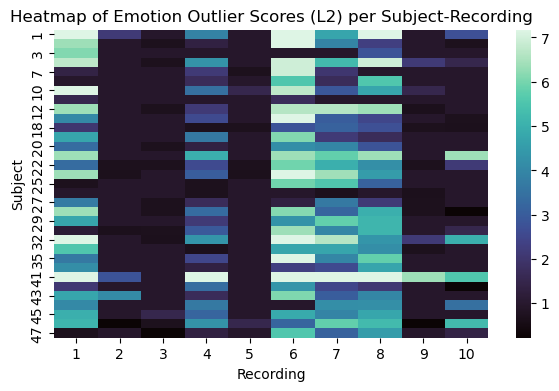

,subject,recording,outlier_score_l2,outlier_score_max,emotion-anger,emotion-tenderness,emotion-sadness,emotion-disgust
266,41,7,7.173558,6.0705,10.0,0.0,10.0,10.0
0,1,1,7.173558,6.0705,10.0,0.0,10.0,10.0
7,1,8,7.173558,6.0705,10.0,0.0,10.0,5.0
267,41,8,7.173558,6.0705,10.0,0.0,10.0,10.0
265,41,6,7.173558,6.0705,10.0,0.0,10.0,10.0
263,41,4,7.173558,6.0705,10.0,0.0,10.0,10.0


In [136]:
# outliers based on emotions 
df_sr = compute_outliers(df_sr, emotion_cols)
plt.figure(figsize=(7, 4))
sns.heatmap(df_sr.pivot(index='subject', columns='recording', values='outlier_score_l2'), cmap='mako')
plt.title('Heatmap of Emotion Outlier Scores (L2) per Subject-Recording')
plt.xlabel('Recording')
plt.ylabel('Subject')
plt.show()

df_sr[['subject','recording','outlier_score_l2','outlier_score_max'] + emotion_cols].head(6)

### Outliers - Subjects

In [137]:
df_s = df.groupby("subject").mean(numeric_only=True).reset_index()
df_s = compute_outliers(df_s, signal_cols)
df_s[['subject','outlier_score_l2','outlier_score_max'] + signal_cols].head(6)

,subject,outlier_score_l2,outlier_score_max,x-avg,y-avg,pupil-size-left-avg,pupil-size-right-avg
14,22,3.692789,2.826763,0.410462,0.640261,4.874643,4.701326
4,7,3.548655,3.444250,0.579060,0.587638,3.229864,3.428564
0,1,2.823192,2.527571,0.491353,0.765006,4.347874,4.327766
11,19,2.530814,2.044951,0.526116,0.721951,3.675706,3.848626
19,28,2.517045,1.608695,0.463214,0.599695,4.914369,4.846812
26,41,2.218842,2.156320,0.428487,0.566708,3.901364,3.478609


In [138]:
df_s = df.groupby("subject").mean(numeric_only=True).reset_index()
df_s = compute_outliers(df_s, emotion_cols)
df_s[['subject','outlier_score_l2','outlier_score_max'] + emotion_cols].head(6)

,subject,outlier_score_l2,outlier_score_max,emotion-anger,emotion-tenderness,emotion-sadness,emotion-disgust
26,41,5.475555,4.125559,7.669952,0.959726,7.488514,7.670034
17,26,4.618173,3.141039,0.058660,1.193718,0.201539,0.825586
7,11,4.048940,2.391130,0.931151,0.291137,0.834013,1.911126
13,21,3.665407,2.814217,6.296406,1.785140,6.050721,6.294212
2,3,3.599887,2.694984,1.520248,1.606197,0.400187,1.255103
22,32,3.571557,2.281859,5.738796,1.978204,6.766994,6.181277


### Outliers - Recordings

In [139]:
df_s = df.groupby("recording").mean(numeric_only=True).reset_index()
df_s = compute_outliers(df_s, signal_cols)
df_s[['recording','outlier_score_l2','outlier_score_max'] + signal_cols].head(6)

,recording,outlier_score_l2,outlier_score_max,x-avg,y-avg,pupil-size-left-avg,pupil-size-right-avg
7,8,3.814796,3.749245,0.481126,0.569565,3.584539,3.602068
0,1,3.081006,2.486875,0.481964,0.526208,3.912487,3.926142
9,10,3.024481,2.235773,0.486739,0.538729,4.013767,4.102991
4,5,2.598139,1.879397,0.471352,0.542918,3.953625,4.039694
6,7,2.100083,1.640900,0.493585,0.554907,3.544199,3.624771
1,2,2.047109,1.662628,0.469940,0.531939,3.733523,3.787000


In [140]:
df_s = df.groupby("recording").mean(numeric_only=True).reset_index()
df_s = compute_outliers(df_s, emotion_cols)
df_s[['recording','outlier_score_l2','outlier_score_max'] + emotion_cols].head(6)

,recording,outlier_score_l2,outlier_score_max,emotion-anger,emotion-tenderness,emotion-sadness,emotion-disgust
4,5,20.210778,20.173689,0.454372,5.538233,0.180790,0.247007
1,2,19.485783,19.449316,0.694601,5.347890,0.149516,0.090371
2,3,4.959962,4.809139,0.459773,1.500896,0.397196,0.093900
8,9,4.668300,4.565958,0.829219,1.436995,1.059077,0.366443
5,6,3.306628,2.724249,7.164605,0.100049,6.793764,7.971032
0,1,2.451480,2.133812,5.999359,0.063399,5.815190,5.340171


## Statistical Analysis: Left vs Right Pupil Size Differences by Subject

In [141]:
# Statistical analysis of left vs right pupil size per subject
df_pupils = df[['subject', 'pupil-size-left-avg', 'pupil-size-right-avg']].dropna()

stats_per_subject = []
for subject in df_pupils['subject'].unique():
    left = df_pupils.loc[df_pupils['subject'] == subject, 'pupil-size-left-avg']
    right = df_pupils.loc[df_pupils['subject'] == subject, 'pupil-size-right-avg']
    
    stats_per_subject.append({
        'subject': subject,
        'n_samples': len(left),
        'corr': left.corr(right),
        'mae': np.abs(left - right).mean(),
        'rmse': np.sqrt(((left - right) ** 2).mean()),
        'max_diff': np.abs(left - right).max(),
        'mean_left': left.mean(),
        'mean_right': right.mean()
    })

df_stats = pd.DataFrame(stats_per_subject).sort_values('mae', ascending=False)
print("Pupil Size Comparison Statistics per Subject (sorted by MAE):\n")
print(df_stats.to_string(index=False))
print(f"\n\nOverall Statistics Across All Subjects:")
print(f"  Median MAE: {df_stats['mae'].median():.3f} mm")
print(f"  Median Correlation: {df_stats['corr'].median():.3f}")
print(f"  Subjects with MAE > 0.5 mm: {(df_stats['mae'] > 0.5).sum()}")
print(f"  Subjects with correlation < 0.9: {(df_stats['corr'] < 0.9).sum()}")

Pupil Size Comparison Statistics per Subject (sorted by MAE):

 subject  n_samples     corr      mae     rmse  max_diff  mean_left  mean_right
      41      72212 0.320186 0.469696 0.595918  1.499951   3.901364    3.478609
       4      55554 0.858650 0.451296 0.511860  1.496897   3.243688    3.691119
      44      72003 0.335817 0.449705 0.537356  1.485933   2.988214    3.108982
       1      46123 0.411576 0.433872 0.486740  1.499762   4.347874    4.327766
      42      72596 0.861316 0.432011 0.466443  1.497155   3.136694    2.705160
      43      71823 0.524117 0.423201 0.554625  1.499943   3.065270    3.293625
      33      71301 0.247449 0.417713 0.523500  3.111453   3.530337    3.461183
       9      69946 0.417601 0.365797 0.452900  1.499387   3.768096    3.627707
       3      53545 0.766084 0.358067 0.491071  4.245839   3.488469    3.773492
      46      70786 0.519645 0.350028 0.441246  2.671374   3.110036    3.442218
      20      72290 0.599294 0.329046 0.420571  1.498721 

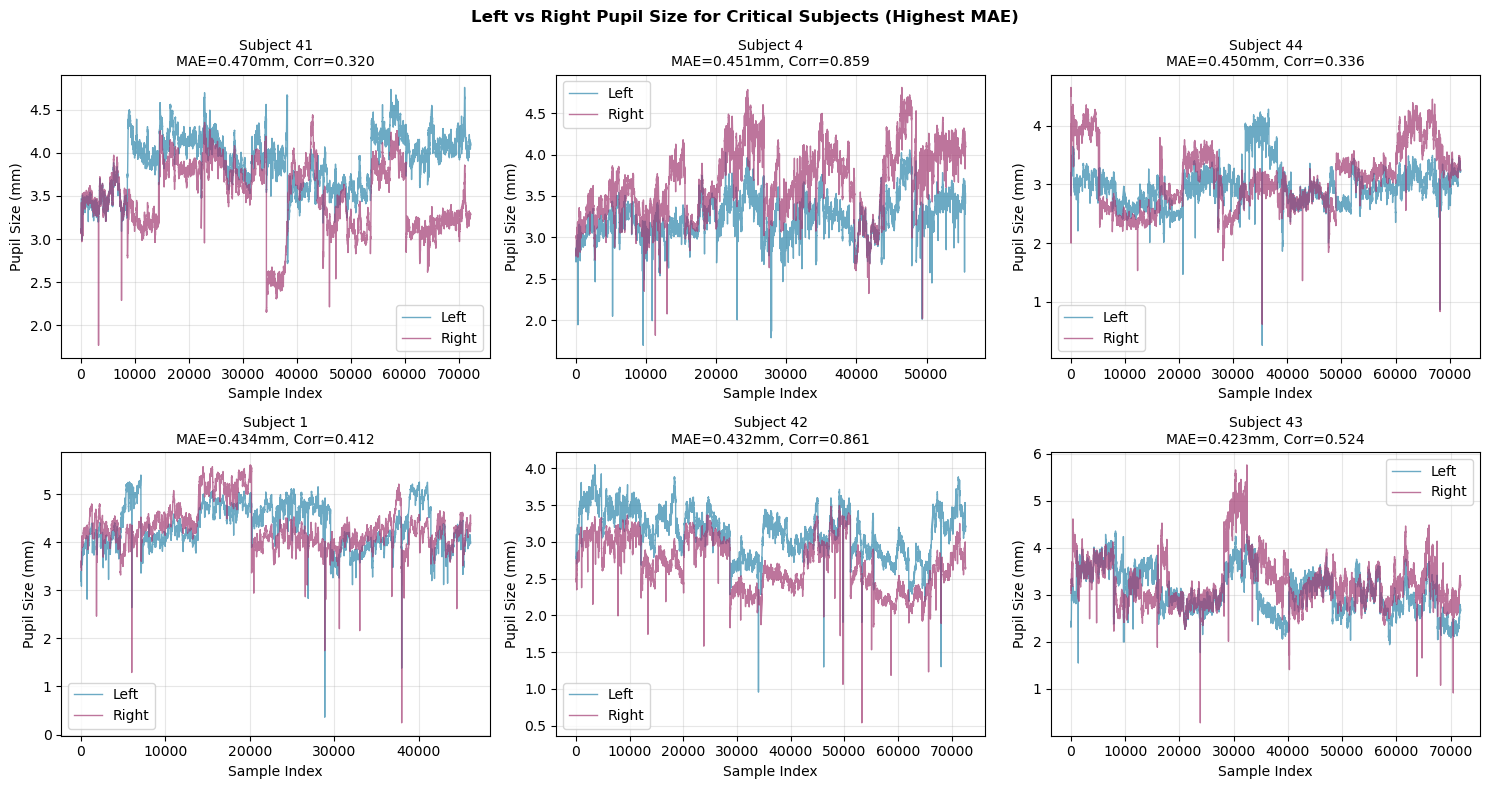

In [142]:
# Plot left vs right pupil sizes for critical subjects (top 6 by MAE)
critical_subjects = df_stats.head(6)['subject'].values
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, subject in enumerate(critical_subjects):
    df_subj = df_pupils[df_pupils['subject'] == subject].reset_index(drop=True)
    left = df_subj['pupil-size-left-avg']
    right = df_subj['pupil-size-right-avg']
    
    ax = axes[idx]
    ax.plot(left.values, label='Left', alpha=0.7, linewidth=1, color='#2E86AB')
    ax.plot(right.values, label='Right', alpha=0.7, linewidth=1, color='#A23B72')
    
    # Add statistics
    stats = df_stats[df_stats['subject'] == subject].iloc[0]
    ax.set_title(f"Subject {subject}\nMAE={stats['mae']:.3f}mm, Corr={stats['corr']:.3f}", fontsize=10)
    ax.set_xlabel('Sample Index')
    ax.set_ylabel('Pupil Size (mm)')
    ax.legend(loc='best')
    ax.grid(alpha=0.3)

plt.suptitle('Left vs Right Pupil Size for Critical Subjects (Highest MAE)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


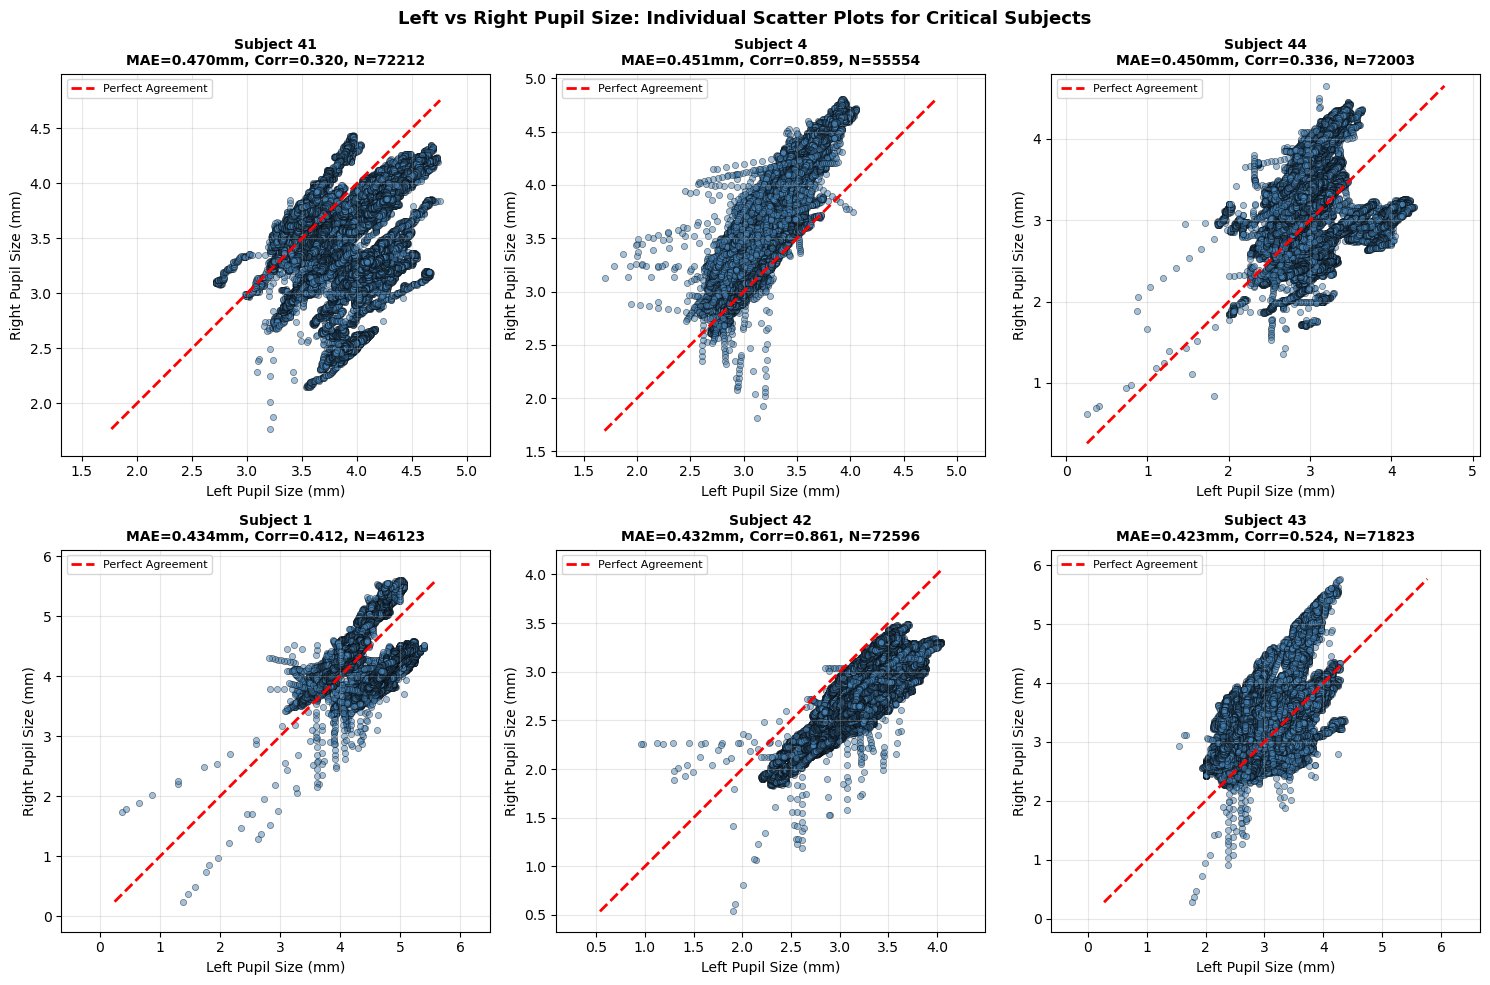

In [143]:
# Scatter plot: left vs right pupil size for each critical subject separately
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, subject in enumerate(critical_subjects):
    df_subj = df_pupils[df_pupils['subject'] == subject].reset_index(drop=True)
    left = df_subj['pupil-size-left-avg']
    right = df_subj['pupil-size-right-avg']
    
    ax = axes[idx]
    ax.scatter(left, right, alpha=0.5, s=20, color='steelblue', edgecolors='black', linewidth=0.5)
    
    # Add perfect agreement line
    min_val = min(left.min(), right.min())
    max_val = max(left.max(), right.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Agreement')
    
    # Add statistics
    stats = df_stats[df_stats['subject'] == subject].iloc[0]
    ax.set_title(f"Subject {subject}\nMAE={stats['mae']:.3f}mm, Corr={stats['corr']:.3f}, N={len(left)}", 
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Left Pupil Size (mm)')
    ax.set_ylabel('Right Pupil Size (mm)')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(alpha=0.3)
    ax.axis('equal')
    
    # Set equal limits
    ax.set_xlim(min_val - 0.5, max_val + 0.5)
    ax.set_ylim(min_val - 0.5, max_val + 0.5)

plt.suptitle('Left vs Right Pupil Size: Individual Scatter Plots for Critical Subjects', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


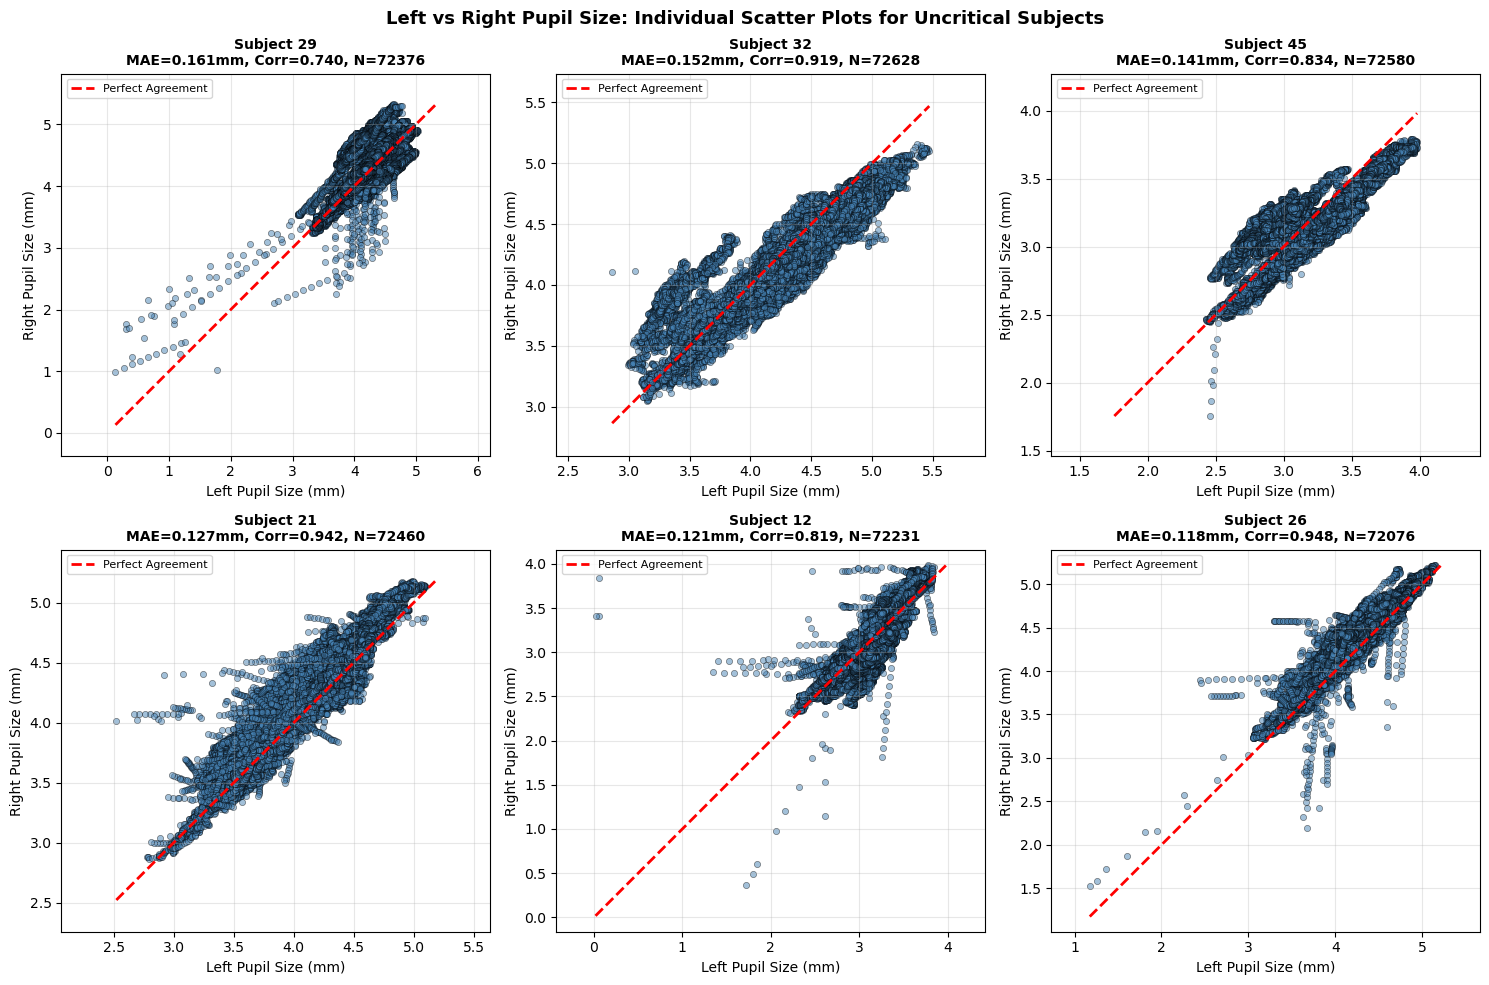

In [144]:
# Scatter plot: left vs right pupil size for each critical subject separately
uncritical_subjects = df_stats.tail(6)['subject'].values
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, subject in enumerate(uncritical_subjects):
    df_subj = df_pupils[df_pupils['subject'] == subject].reset_index(drop=True)
    left = df_subj['pupil-size-left-avg']
    right = df_subj['pupil-size-right-avg']
    
    ax = axes[idx]
    ax.scatter(left, right, alpha=0.5, s=20, color='steelblue', edgecolors='black', linewidth=0.5)
    
    # Add perfect agreement line
    min_val = min(left.min(), right.min())
    max_val = max(left.max(), right.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Agreement')
    
    # Add statistics
    stats = df_stats[df_stats['subject'] == subject].iloc[0]
    ax.set_title(f"Subject {subject}\nMAE={stats['mae']:.3f}mm, Corr={stats['corr']:.3f}, N={len(left)}", 
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Left Pupil Size (mm)')
    ax.set_ylabel('Right Pupil Size (mm)')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(alpha=0.3)
    ax.axis('equal')
    
    # Set equal limits
    ax.set_xlim(min_val - 0.5, max_val + 0.5)
    ax.set_ylim(min_val - 0.5, max_val + 0.5)

plt.suptitle('Left vs Right Pupil Size: Individual Scatter Plots for Uncritical Subjects', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Percentage of Outlier Points within Each Subject

In [145]:
# Calculate percentage of outlier points within each subject
# Define outliers as points where |left - right| exceeds a threshold based on robust statistics

outlier_results = []

for subject in df_pupils['subject'].unique():
    df_subj = df_pupils[df_pupils['subject'] == subject]
    left = df_subj['pupil-size-left-avg']
    right = df_subj['pupil-size-right-avg']
    
    # Calculate differences
    diff = np.abs(left - right)
    
    # Robust outlier detection: MAD-based threshold
    median_diff = np.median(diff)
    mad = np.median(np.abs(diff - median_diff))
    
    # Outliers: points > median + 3*MAD (robust version of 3-sigma rule)
    threshold = median_diff + 3 * 1.4826 * mad  # 1.4826 makes MAD consistent with std for normal dist
    outliers = diff > threshold
    n_outliers = outliers.sum()
    pct_outliers = (n_outliers / len(diff)) * 100
    
    outlier_results.append({
        'subject': subject,
        'n_points': len(diff),
        'n_outliers': n_outliers,
        'pct_outliers': pct_outliers,
        'median_diff': median_diff,
        'mad': mad,
        'threshold': threshold,
        'max_diff': diff.max()
    })

df_outliers = pd.DataFrame(outlier_results).sort_values('pct_outliers', ascending=False)

print("Outlier Analysis per Subject (sorted by % outliers):\n")
print(df_outliers.to_string(index=False))
print(f"\n\nSummary Statistics:")
print(f"  Median % outliers across subjects: {df_outliers['pct_outliers'].median():.2f}%")
print(f"  Subjects with >10% outliers: {(df_outliers['pct_outliers'] > 10).sum()}")
print(f"  Subjects with >5% outliers: {(df_outliers['pct_outliers'] > 5).sum()}")

Outlier Analysis per Subject (sorted by % outliers):

 subject  n_points  n_outliers  pct_outliers  median_diff      mad  threshold  max_diff
      35     72208        8753     12.121926     0.167075 0.118130   0.692492  1.499937
      29     72376        7012      9.688294     0.110582 0.064933   0.399392  1.489115
      45     72580        5844      8.051805     0.124671 0.036829   0.288477  0.701869
      14     72010        5684      7.893348     0.175140 0.075805   0.512305  1.469870
      47     72390        5428      7.498273     0.197992 0.117126   0.718943  3.847661
       3     53545        3555      6.639275     0.232681 0.164018   0.962198  4.245839
      46     70786        3964      5.599977     0.261676 0.143354   0.899285  2.671374
      33     71301        3683      5.165425     0.341423 0.168744   1.091962  3.111453
      30     72145        3428      4.751542     0.124489 0.083242   0.494734  3.791220
      41     72212        3299      4.568493     0.364874 0.212616

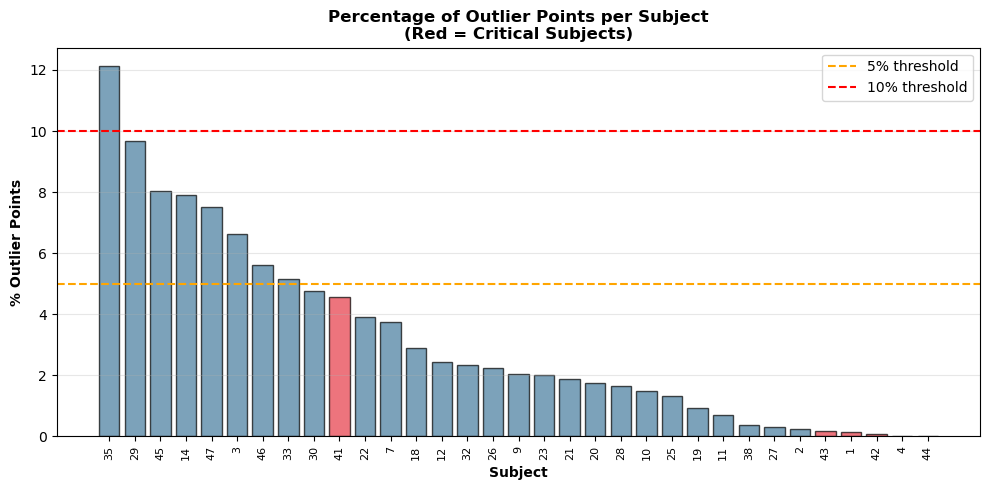



Detailed Outlier Analysis for Critical Subjects:

Subject 41:
  Total points: 72212.0
  Outlier points: 3299.0 (4.57%)
  Median |left-right| difference: 0.365 mm
  MAD: 0.213 mm
  Outlier threshold: 1.311 mm
  Max difference: 1.500 mm

Subject 4:
  Total points: 55554.0
  Outlier points: 16.0 (0.03%)
  Median |left-right| difference: 0.496 mm
  MAD: 0.199 mm
  Outlier threshold: 1.382 mm
  Max difference: 1.497 mm

Subject 44:
  Total points: 72003.0
  Outlier points: 9.0 (0.01%)
  Median |left-right| difference: 0.382 mm
  MAD: 0.224 mm
  Outlier threshold: 1.379 mm
  Max difference: 1.486 mm

Subject 1:
  Total points: 46123.0
  Outlier points: 68.0 (0.15%)
  Median |left-right| difference: 0.392 mm
  MAD: 0.155 mm
  Outlier threshold: 1.080 mm
  Max difference: 1.500 mm

Subject 42:
  Total points: 72596.0
  Outlier points: 61.0 (0.08%)
  Median |left-right| difference: 0.452 mm
  MAD: 0.124 mm
  Outlier threshold: 1.003 mm
  Max difference: 1.497 mm

Subject 43:
  Total points: 7

In [146]:
# Visualize outlier percentages for critical subjects
fig, ax = plt.subplots(figsize=(10, 5))

# Highlight critical subjects
colors = ['#E63946' if subj in critical_subjects else '#457B9D' 
          for subj in df_outliers['subject']]

bars = ax.bar(range(len(df_outliers)), df_outliers['pct_outliers'], color=colors, alpha=0.7, edgecolor='black')
ax.set_xlabel('Subject', fontweight='bold')
ax.set_ylabel('% Outlier Points', fontweight='bold')
ax.set_title('Percentage of Outlier Points per Subject\n(Red = Critical Subjects)', fontsize=12, fontweight='bold')
ax.set_xticks(range(len(df_outliers)))
ax.set_xticklabels(df_outliers['subject'], rotation=90, fontsize=8)
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=5, color='orange', linestyle='--', linewidth=1.5, label='5% threshold')
ax.axhline(y=10, color='red', linestyle='--', linewidth=1.5, label='10% threshold')
ax.legend()

plt.tight_layout()
plt.show()

# Print detailed info for critical subjects
print("\n\nDetailed Outlier Analysis for Critical Subjects:")
print("=" * 80)
for subject in critical_subjects:
    info = df_outliers[df_outliers['subject'] == subject].iloc[0]
    print(f"\nSubject {subject}:")
    print(f"  Total points: {info['n_points']}")
    print(f"  Outlier points: {info['n_outliers']} ({info['pct_outliers']:.2f}%)")
    print(f"  Median |left-right| difference: {info['median_diff']:.3f} mm")
    print(f"  MAD: {info['mad']:.3f} mm")
    print(f"  Outlier threshold: {info['threshold']:.3f} mm")
    print(f"  Max difference: {info['max_diff']:.3f} mm")

### Analyse "nice" subjects

In [147]:
# nice_subjects = [12, 21, 26, 29, 32, 45]
# picked_emotion = "emotion-anger"
# binary = True # 0 vs 1+ intensities

# dftemp = df[df['subject'].isin(nice_subjects)]
# dftemp = dftemp[[picked_emotion, 'subject', 'recording', 'x-avg', 'y-avg', 'pupil-size-left-avg', 'pupil-size-right-avg']].dropna()

# print("label distribution for nice subjects - histograms of emotion values for each subject-emotion pair separately")
# for subject in nice_subjects:
#     df_subj = dftemp[dftemp['subject'] == subject]
#     df_sr_subj = df_subj.dropna().drop_duplicates(subset=["recording"])[["recording"] + [picked_emotion]]
#     print(f"\nSubject {subject}:")
#     for emotion in [picked_emotion]:
#         data = df_sr_subj[emotion].dropna()
#         if binary:
#             data = (data > 0).astype(int)
#         min_val = data.min()
#         max_val = data.max()
#         count = len(data)
#         print(f"  {emotion}: Min={min_val:.2f}, Max={max_val:.2f}, Count={count}")
        
#         plt.figure(figsize=(5, 3))
#         plt.hist(data, bins=range(0, 3), alpha=0.7, color='steelblue', edgecolor='black')
#         plt.title(f"Subject {subject} - Distribution of {emotion}\nMin: {min_val:.2f}, Max: {max_val:.2f}, Count: {count}")
#         plt.xlabel("Emotion Intensity")
#         plt.ylabel("Frequency")
#         plt.xticks(range(0, 3))
#         plt.grid(axis='y', alpha=0.3)
#         plt.show()




In [148]:

# print("pupil size distribution for nice subjects - histogram")
# for subject in nice_subjects:
#     df_subj = dftemp[dftemp['subject'] == subject]
#     df_sr_subj = df_subj.dropna()[["recording"] + [picked_emotion] + ['pupil-size-left-avg', 'pupil-size-right-avg']]
    
#     for emotion in [picked_emotion]:
#             plt.figure(figsize=(5, 3))
#             data_left_pos = df_sr_subj.loc[df_sr_subj[emotion] > 0, 'pupil-size-left-avg']
#             data_right_pos = df_sr_subj.loc[df_sr_subj[emotion] > 0, 'pupil-size-right-avg']
            
#             data_left_neg = df_sr_subj.loc[df_sr_subj[emotion] == 0, 'pupil-size-left-avg']
#             data_right_neg = df_sr_subj.loc[df_sr_subj[emotion] == 0, 'pupil-size-right-avg']
#             plt.hist(data_left_pos, bins=30, alpha=0.5, label='Left Pupil Size (emotion>0)', color='blue', density=True, weights=np.ones(len(data_left_pos)) / len(df_sr_subj) * 100)
#             plt.hist(data_left_neg, bins=30, alpha=0.5, label='Left Pupil Size (emotion=0)', color='lightblue', density=True, weights=np.ones(len(data_left_neg)) / len(df_sr_subj) * 100)
#             plt.hist(data_right_pos, bins=30, alpha=0.5, label='Right Pupil Size (emotion>0)', color='orange', density=True, weights=np.ones(len(data_right_pos)) / len(df_sr_subj) * 100)
#             plt.hist(data_right_neg, bins=30, alpha=0.5, label='Right Pupil Size (emotion=0)', color='peachpuff', density=True, weights=np.ones(len(data_right_neg)) / len(df_sr_subj) * 100)
            
#             plt.title(f"Subject {subject} - Pupil Size Distribution for {emotion} > 0")
#             plt.xlabel("Pupil Size (mm)")
#             plt.ylabel("Frequency")
#             plt.legend()
#             plt.show()


## Coordinates per subject/recording
Statistical analysis of x-avg and y-avg 
1. sequential plot over all recordings per subject and 


In [149]:
import os
save_dir = "./plots-EDA/coordinates-line-plots-cleaned"
os.makedirs(save_dir, exist_ok=True)
df = dfOG.copy()
print(df.columns)
for subject in df['subject'].unique():
    df_subj = df[df['subject'] == subject]
    # line plot of x-avg and y-avg
    # vertical line at recording boundaries (when recording changes)
    # horizontal dotted lines of emotion anger - 0 if 0 and 1 if >0
    # df_subj = df_subj.iloc[::10]   # keep every 10th row for faster plotting
    df_subj = df_subj.reset_index(drop=True)

    # # filter with savitzky-golay to smooth out the lines for better visualization
    # from scipy.signal import savgol_filter
    # df_subj['x-avg'] = savgol_filter(df_subj['x-avg'], window_length=11, polyorder=3, mode='nearest')
    # df_subj['y-avg'] = savgol_filter(df_subj['y-avg'], window_length=11, polyorder=3, mode='nearest')

    # plot only the problematic ones
    if df_subj['x-avg'].between(0, 1).sum() > len(df_subj) * 0.99 or df_subj['y-avg'].between(0, 1).sum() > len(df_subj) * 0.99:
        continue

    df_subj['x-avg'] = df_subj[df_subj['x-avg'].between(0, 1)]['x-avg']
    df_subj['y-avg'] = df_subj[df_subj['y-avg'].between(0, 1)]['y-avg']
    
    plt.figure(figsize=(20, 4))
    # plt.plot(df_subj['time-rel-seconds'], marker='o')
    plt.plot(df_subj['x-avg'], label='x-avg', color='steelblue', alpha=0.5)
    plt.plot(df_subj['y-avg'], label='y-avg', color='orange', alpha=0.5)
    # Add vertical lines at recording boundaries
    # indices where recording changes vs previous row
    flip_idx = df_subj.index[df_subj['recording'].ne(df_subj['recording'].shift())].tolist()


    recording_changes = df_subj.index[df_subj['recording'].ne(df_subj['recording'].shift())][1:]

    plt.vlines(recording_changes, ymin=0, ymax=1,
            colors='gray', linestyles='--', alpha=0.5, linewidth=1)

    plt.title(f"Subject {subject} - x-avg and y-avg with Recording Boundaries and Emotion Anger Levels")
    plt.xlabel("Sample Index")
    plt.ylabel("Value")
    plt.legend()
    # plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{save_dir}/subject_{subject}_x_avg_y_avg.png")
    print(f"Saved plot for subject {subject}")
    plt.close()
print("Plots saved to directory:", save_dir)
df_subj

Index(['time-rel-seconds', 'x-avg', 'y-avg', 'confidence-gaze-left',
       'confidence-gaze-right', 'pupil-size-left-avg', 'pupil-size-right-avg',
       'subject', 'recording', 'emotion-anger', 'emotion-tenderness',
       'emotion-sadness', 'emotion-disgust'],
      dtype='object')
Saved plot for subject 7
Saved plot for subject 3
Saved plot for subject 46
Saved plot for subject 27
Plots saved to directory: ./plots-EDA/coordinates-line-plots-cleaned


,time-rel-seconds,x-avg,y-avg,confidence-gaze-left,confidence-gaze-right,pupil-size-left-avg,pupil-size-right-avg,subject,recording,emotion-anger,emotion-tenderness,emotion-sadness,emotion-disgust
0,0.00,0.394203,0.394705,0.996312,0.996312,3.548717,3.357499,11,4,0.0,0.0,0.0,0.0
1,0.01,0.395809,0.403861,0.962226,0.962226,3.530882,3.344365,11,4,0.0,0.0,0.0,0.0
2,0.02,0.397415,0.413017,0.928140,0.928140,3.516288,3.371851,11,4,0.0,0.0,0.0,0.0
3,0.03,0.400318,0.408627,0.997550,0.997550,3.507212,3.394746,11,4,0.0,0.0,0.0,0.0
4,0.04,0.402347,0.410185,0.998699,0.998699,3.517777,3.438441,11,4,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72640,78.88,0.427468,0.609053,0.996134,0.996134,5.330487,5.175896,11,5,0.0,1.0,0.0,0.0
72641,78.89,0.434110,0.604921,0.996696,0.996696,5.301778,5.173323,11,5,0.0,1.0,0.0,0.0
72642,78.90,0.466704,0.607767,0.996235,0.996235,5.273285,5.159599,11,5,0.0,1.0,0.0,0.0
72643,78.91,0.485790,0.611852,0.996030,0.996030,5.251440,5.144619,11,5,0.0,1.0,0.0,0.0


In [150]:
df = dfOG.copy()
# remove subjects 3 and 7 and save cleaned dataframe to pupil_x_y_cleaned_data_path
df = df[~df['subject'].isin([3, 7])]
import os
os.makedirs(os.path.dirname(pupil_x_y_cleaned_data_path), exist_ok=True)
df.to_csv(pupil_x_y_cleaned_data_path, index=False)
print(f"Cleaned data saved to {pupil_x_y_cleaned_data_path}")

Cleaned data saved to ../../data/processed/eSEEd_v2_cleaned/eSEEd_pupil_x_y_cleaned.csv
